In [ ]:
import os
from getpass import getpass
os.environ['KAGGLE_API_TOKEN'] = getpass('KGAT_9bb4a564be194cbbbb26b775e12d9c22')

KGAT_9bb4a564be194cbbbb26b775e12d9c22··········


In [ ]:
!pip install -q kaggle
!mkdir -p ~/.kaggle
!echo "{\"username\":\"samiltokat\",\"key\":\"$KAGGLE_API_TOKEN\"}" > ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
csv_dosyalari = [
    "movies.csv", "actors.csv", "countries.csv", "crew.csv", "genres.csv",
    "languages.csv", "posters.csv", "releases.csv", "studios.csv", "themes.csv"
]

for dosya in csv_dosyalari:
    print(f"--- {dosya} indiriliyor ---")
    !kaggle datasets download -d gsimonx37/letterboxd -f {dosya}
    !unzip -o -q {dosya}.zip

--- movies.csv indiriliyor ---
Dataset URL: https://www.kaggle.com/datasets/gsimonx37/letterboxd
License(s): GPL-3.0
movies.csv.zip: Skipping, found more recently modified local copy (use --force to force download)
--- actors.csv indiriliyor ---
Dataset URL: https://www.kaggle.com/datasets/gsimonx37/letterboxd
License(s): GPL-3.0
actors.csv.zip: Skipping, found more recently modified local copy (use --force to force download)
--- countries.csv indiriliyor ---
Dataset URL: https://www.kaggle.com/datasets/gsimonx37/letterboxd
License(s): GPL-3.0
countries.csv.zip: Skipping, found more recently modified local copy (use --force to force download)
--- crew.csv indiriliyor ---
Dataset URL: https://www.kaggle.com/datasets/gsimonx37/letterboxd
License(s): GPL-3.0
crew.csv.zip: Skipping, found more recently modified local copy (use --force to force download)
--- genres.csv indiriliyor ---
Dataset URL: https://www.kaggle.com/datasets/gsimonx37/letterboxd
License(s): GPL-3.0
genres.csv.zip: Skipp

In [ ]:
!ls -lh *.csv

-rw-r--r-- 1 root root 187M Jun 27  2024 actors.csv
-rw-r--r-- 1 root root  11M Jun 27  2024 countries.csv
-rw-r--r-- 1 root root 155M Jun 27  2024 crew.csv
-rw-r--r-- 1 root root  18M Jun 27  2024 genres.csv
-rw-r--r-- 1 root root  28M Jun 27  2024 languages.csv
-rw-r--r-- 1 root root  11M Jul 28 12:02 movies_clean.csv
-rw-r--r-- 1 root root 243M Jun 27  2024 movies.csv
-rw-r--r-- 1 root root  91M Jun 27  2024 posters.csv
-rw-r--r-- 1 root root  49M Jun 27  2024 releases.csv
-rw-r--r-- 1 root root  18M Jun 27  2024 studios.csv
-rw-r--r-- 1 root root 5.4M Jun 27  2024 themes.csv


In [ ]:
import pandas as pd

# Pandas'ın çok sütunlu tablolarda bazı sütunları "..." ile gizlemesini engelliyoruz,
# böylece her tablonun TÜM sütunlarını eksiksiz görebiliyoruz
pd.set_option('display.max_columns', None)

# İncelemek istediğimiz tüm CSV dosyalarının isimlerini bir listede topluyoruz
# (movies.csv'yi zaten önceden gördüğümüz için buraya eklemedik, tekrar bakmaya gerek yok)
tablolar = ["actors", "genres", "crew", "studios", "countries", "languages", "themes", "releases"]

# Her tabloyu TEK TEK, sadece ilk 5 satırıyla okuyoruz (nrows=5)
# Neden sadece 5 satır: amacımız veriyi analiz etmek değil, YAPISINI görmek
# (hangi sütunlar var, veri tipi ne, id nasıl bağlanıyor) - bu yüzden RAM harcamaya gerek yok
for tablo in tablolar:
    df_ornek = pd.read_csv(f"{tablo}.csv", nrows=5)

    # Her tablonun adını, sütun isimlerini ve toplam sütun sayısını yazdırıyoruz
    # Bu bilgi, hangi tabloların birbirine "id" üzerinden bağlanabileceğini görmemizi sağlıyor
    print(f"\n{'='*60}")
    print(f"{tablo.upper()}.csv")
    print(f"Sütunlar: {list(df_ornek.columns)}")
    print(f"Sütun sayısı: {df_ornek.shape[1]}")
    print(df_ornek)


ACTORS.csv
Sütunlar: ['id', 'name', 'role']
Sütun sayısı: 3
        id               name    role
0  1000001      Margot Robbie  Barbie
1  1000001       Ryan Gosling     Ken
2  1000001    America Ferrera  Gloria
3  1000001  Ariana Greenblatt   Sasha
4  1000001           Issa Rae  Barbie

GENRES.csv
Sütunlar: ['id', 'genre']
Sütun sayısı: 2
        id      genre
0  1000001     Comedy
1  1000001  Adventure
2  1000002     Comedy
3  1000002   Thriller
4  1000002      Drama

CREW.csv
Sütunlar: ['id', 'role', 'name']
Sütun sayısı: 3
        id      role            name
0  1000001  Director    Greta Gerwig
1  1000001  Producer    Tom Ackerley
2  1000001  Producer   Margot Robbie
3  1000001  Producer  Robbie Brenner
4  1000001  Producer    David Heyman

STUDIOS.csv
Sütunlar: ['id', 'studio']
Sütun sayısı: 2
        id                   studio
0  1000001  LuckyChap Entertainment
1  1000001             Heyday Films
2  1000001           NB/GG Pictures
3  1000001                   Mattel
4  10000

In [ ]:
import pandas as pd

# ============================================================
# 1. ANA TABLO: movies.csv
# ============================================================
# movies.csv'de toplam 7 sütun var: id, name, date, tagline, description, minute, rating
# tagline ve description'ı BİLEREK ALMIYORUZ (usecols listesine koymadık):
# - İkisi de serbest metin (film sloganı ve açıklaması)
# - Sayısal/kategorik bir ML modeline direkt veremeyiz, anlamlı kullanım için NLP gerekir
# - usecols sayesinde bu ikisini pandas hiç OKUMUYOR bile -> RAM tasarrufu
df_movies = pd.read_csv("movies.csv", usecols=["id", "name", "date", "minute", "rating"])
print("movies:", df_movies.shape)

# ============================================================
# 2. GENRES.csv — toplam 2 sütun: id, genre
# ============================================================
# İkisini de alıyoruz (filtre yok) çünkü zaten sadece 2 sütun var, atacak sütun yok
df_genres = pd.read_csv("genres.csv")
# Bir filmin birden fazla türü olabiliyor (uzun format) -> aynı id'ye sahip satırları grupluyoruz
# .first() -> her filmin İLK sırada yazan türünü "ana tür" olarak alıyoruz
genre_main = df_genres.groupby("id")["genre"].first().rename("genre_main")
# .size() -> her filmin kaç farklı türü olduğunu sayıyoruz
genre_count = df_genres.groupby("id").size().rename("genre_count")
genre_summary = pd.concat([genre_main, genre_count], axis=1).reset_index()
print("genres özet:", genre_summary.shape)

# ============================================================
# 3. ACTORS.csv — toplam 3 sütun: id, name, role
# ============================================================
# SADECE id'yi alıyoruz, name (oyuncu adı) ve role'ü (canlandırdığı karakter) ALMIYORUZ:
# - Bu tablo 1.6M+ satır, oyuncu isimleri ÇOK yüksek kardiniteli (binlerce farklı isim)
# - İsimleri kategorik değişken olarak kullanmak modelde yönetilemez/anlamsız olur
# - Bize sadece "bu filmde kaç oyuncu oynamış" SAYISI lazım
# usecols=["id"] ile name/role'ü hiç okumuyoruz -> hem RAM hem işlem hızı kazancı
df_actors = pd.read_csv("actors.csv", usecols=["id"])
actor_count = df_actors.groupby("id").size().rename("actor_count").reset_index()
print("actors özet:", actor_count.shape)

# ============================================================
# 4. CREW.csv — toplam 3 sütun: id, role, name
# ============================================================
# Üçünü de alıyoruz ama İKİ farklı amaç için kullanıyoruz:
df_crew = pd.read_csv("crew.csv")
# Amaç 1: role sütununu FİLTRELEMEK için kullanıyoruz (sadece "Director" olan satırlar)
# name'i bu filtrelenmiş satırdan yönetmen adını almak için kullanıyoruz
director = df_crew[df_crew["role"] == "Director"].groupby("id")["name"].first().rename("director")
# Amaç 2: aynı tablodan (filtre UYGULAMADAN) toplam satır sayısını da alıyoruz
# -> bu bize "ekip ne kadar büyük" (yönetmen+prodüktör+vs. toplam kişi sayısı) bilgisini veriyor
crew_size = df_crew.groupby("id").size().rename("crew_size")
crew_summary = pd.concat([director, crew_size], axis=1).reset_index()
print("crew özet:", crew_summary.shape)

# ============================================================
# 5. STUDIOS.csv — toplam 2 sütun: id, studio
# ============================================================
# genres ile aynı mantık: atacak sütun yok, ikisini de alıyoruz
df_studios = pd.read_csv("studios.csv")
studio_main = df_studios.groupby("id")["studio"].first().rename("studio_main")
studio_count = df_studios.groupby("id").size().rename("studio_count")
studio_summary = pd.concat([studio_main, studio_count], axis=1).reset_index()
print("studios özet:", studio_summary.shape)

# ============================================================
# 6. COUNTRIES.csv — toplam 2 sütun: id, country
# ============================================================
# Aynı mantık: atacak sütun yok, ana ülke + ülke sayısını çıkarıyoruz
df_countries = pd.read_csv("countries.csv")
country_main = df_countries.groupby("id")["country"].first().rename("country_main")
country_count = df_countries.groupby("id").size().rename("country_count")
country_summary = pd.concat([country_main, country_count], axis=1).reset_index()
print("countries özet:", country_summary.shape)

# ============================================================
# 7. LANGUAGES.csv — toplam 3 sütun: id, type, language
# ============================================================
# Üçünü de alıyoruz çünkü type sütunu olmadan hangi dilin "asıl dil" olduğunu ayırt edemeyiz
df_languages = pd.read_csv("languages.csv")
# type sütunu "Primary language / Language / Spoken language" gibi değerler taşıyor
# Buna göre bir ÖNCELİK SIRASI kuruyoruz (küçük sayı = daha önemli/asıl dil)
priority = {"Primary language": 0, "Language": 1, "Spoken language": 2}
df_languages["priority"] = df_languages["type"].map(priority)
# Her film için önceliği en düşük (yani en önemli) satır üste gelecek şekilde sıralıyoruz
df_languages_sorted = df_languages.sort_values(["id", "priority"])
# .first() ile her filmin en yüksek öncelikli dilini "ana dil" olarak seçiyoruz
language_main = df_languages_sorted.groupby("id")["language"].first().rename("language_main").reset_index()
print("languages özet:", language_main.shape)

# ============================================================
# 8. THEMES.csv — toplam 2 sütun: id, theme
# ============================================================
# SADECE id'yi alıyoruz, theme'i (tema açıklaması) ALMIYORUZ:
# - actors.csv'deki mantığın aynısı: theme metni serbest/çok çeşitli
#   (örn. "Humanity and the world around us" gibi yüzlerce farklı ifade)
# - Bize sadece "kaç tema etiketlenmiş" SAYISI lazım, temaların kendisi değil
df_themes = pd.read_csv("themes.csv", usecols=["id"])
theme_count = df_themes.groupby("id").size().rename("theme_count").reset_index()
print("themes özet:", theme_count.shape)

# ============================================================
# 9. RELEASES.csv — toplam 5 sütun: id, country, date, type, rating
# ============================================================
# SADECE id ve country'yi alıyoruz; date, type, rating'i ALMIYORUZ:
# - rating burada içerik SERTİFİKASI demek (PG, ATP gibi, yaş sınırı kodu),
#   movies.csv'deki asıl HEDEF DEĞİŞKENİMİZ olan rating (puan, 0-5) ile
#   İSİM ÇAKIŞMASI riski taşıyor -> karışıklık olmasın diye BİLEREK dışarıda bıraktık
# - date (vizyon tarihi) ve type (Theatrical/Digital) şimdiki hedefimiz için gerekli değil,
#   ileride ek analiz yapmak istersek geri dönüp ekleyebiliriz
df_releases = pd.read_csv("releases.csv", usecols=["id", "country"])
# .nunique() -> her film için KAÇ FARKLI ülkede vizyona girdiğini sayıyoruz
# (aynı ülkede birden fazla vizyon tarihi olabilir, o yüzden count değil nunique kullanıyoruz)
release_country_count = df_releases.groupby("id")["country"].nunique().rename("release_country_count").reset_index()
print("releases özet:", release_country_count.shape)

movies: (941597, 5)
genres özet: (676491, 3)
actors özet: (634302, 2)
crew özet: (807062, 3)
studios özet: (438197, 3)
countries özet: (617192, 3)
languages özet: (905578, 2)
themes özet: (24508, 2)
releases özet: (826018, 2)


In [ ]:
# ============================================================
# TÜM ÖZET TABLOLARI movies.csv'YE BİRLEŞTİRİYORUZ
# ============================================================
# how="left" kullanıyoruz -> movies.csv'deki TÜM 941,597 filmi koruyoruz,
# eşleşme bulunamayan (örn. tema bilgisi olmayan) filmlerde o sütun NaN (boş) kalacak,
# hiçbir film satırı SİLİNMEYECEK (inner join yapsaydık, örn. sadece 24 bin filme düşerdik!)
df_final = (
    df_movies
    .merge(genre_summary, on="id", how="left")
    .merge(actor_count, on="id", how="left")
    .merge(crew_summary, on="id", how="left")
    .merge(studio_summary, on="id", how="left")
    .merge(country_summary, on="id", how="left")
    .merge(language_main, on="id", how="left")
    .merge(theme_count, on="id", how="left")
    .merge(release_country_count, on="id", how="left")
)

print("Birleşik tablo boyutu:", df_final.shape)
# Kontrol: movies.csv'deki satır sayısıyla AYNI olmalı (941,597) -> left join satır kaybetmemeli

Birleşik tablo boyutu: (941597, 17)


In [ ]:
# Sayısal sütunlarda eksik olan yerler -> 0 (bu bilgi mevcut değilse, sayısı 0 kabul ediyoruz)
numeric_columns = ["genre_count", "actor_count", "crew_size", "studio_count",
                   "country_count", "theme_count", "release_country_count"]
df_final[numeric_columns] = df_final[numeric_columns].fillna(0)

# Kategorik sütunlarda eksik olan yerler -> "Unknown" (ayrı bir kategori olarak)
categorical_columns = ["genre_main", "director", "studio_main", "country_main", "language_main"]
df_final[categorical_columns] = df_final[categorical_columns].fillna("Unknown")

# Son kontrol: rating hariç artık hiçbir sütunda eksik değer kalmamalı
print(df_final.isnull().sum())

id                            0
name                         10
date                      91913
minute                   181570
rating                   850598
genre_main                    0
genre_count                   0
actor_count                   0
director                      0
crew_size                     0
studio_main                   0
studio_count                  0
country_main                  0
country_count                 0
language_main                 0
theme_count                   0
release_country_count         0
dtype: int64


In [ ]:
# Rating (hedef değişkenimiz) sütununu bilerek eksik değer doldurma listesine almadık
# Bu bizim tahmin etmeye çalıştığımız değer — eğer bir filmin rating'i eksikse (henüz yeterli oy almamışsa), o filmi modelin eğitiminde/testinde kullanamayız.
# Eksik değeri "0" veya ortalama ile doldurmak, modele yanlış/uydurma bir sinyal vermek olur.
# Bu yüzden rating'in kendi eksik durumuna ayrıca bakalım,

In [ ]:
# rating sütununda kaç satırda eksik değer var, kontrol edelim
print(f"Rating eksik satır sayısı: {df_final['rating'].isnull().sum()}")
print(f"Toplam satır sayısı: {len(df_final)}")

# Rating'i eksik olan satırları veri setinden ÇIKARIYORUZ (doldurmuyoruz)
# çünkü bu bizim tahmin etmeye çalıştığımız hedef değişken
df_final_clean = df_final.dropna(subset=["rating"]).reset_index(drop=True)
print(f"\nRating temizlendikten sonra kalan satır sayısı: {df_final_clean.shape}")

Rating eksik satır sayısı: 850598
Toplam satır sayısı: 941597

Rating temizlendikten sonra kalan satır sayısı: (90999, 17)


In [ ]:
# Çok net ve beklenen bir sonuç çıktı — ama önemli olduğu için birlikte yorumlayalım:

# Rating'i olmayan 850,598 film (%90.3) veri setinden çıktı, geriye 90,999 film (%9.7) kaldı.

# Bu bir hata değil, Letterboxd'un doğal yapısından kaynaklanıyor: platformdaki milyonlarca filmin büyük kısmı çok az izlenmiş/oylanmış (obscure, niş, eski veya yerel yapımlar)
# — yeterli oy toplamadığı için ortalama puan hesaplanamamış. Bu yüzden "rating'i olan" alt küme, doğal olarak filmlerin küçük bir kısmı.

# Bu bir sorun mu? Hayır — 91 bin satır, ML modeli için hâlâ fazlasıyla yeterli. Karşılaştırma için: US Accidents projesinde bile modelleme için genelde örnekleme yapmayı düşünüyorduk
# (7.7M çok fazlaydı); burada 91K zaten "temiz ve yönetilebilir" bir boyut, örnekleme yapmamıza bile gerek kalmayabilir.

# Şimdi önemli bir sonraki adım: date (91,913 eksik) ve minute (181,570 eksik) sayıları tüm 941K film üzerinden hesaplanmıştı — rating'i olan 91K filmde bu eksiklik oranı çok daha düşük olabilir
# (çünkü rating alan filmler genelde daha eksiksiz kataloglanmış, popüler yapımlar). Bunu doğrulayalım:

In [ ]:
# df_final_clean (rating'i olan 91K film) İÇİNDE eksik değerleri kontrol ediyoruz
# Yukarıdaki eksik değer sayıları TÜM 941K film üzerinden hesaplanmıştı,
# rating'i olan alt kümede durum farklı (muhtemelen daha az eksik) olabilir
print(df_final_clean.isnull().sum())

id                         0
name                       0
date                       0
minute                   524
rating                     0
genre_main                 0
genre_count                0
actor_count                0
director                   0
crew_size                  0
studio_main                0
studio_count               0
country_main               0
country_count              0
language_main              0
theme_count                0
release_country_count      0
dtype: int64


In [ ]:
# Tam tahmin ettiğimiz gibi çıktı — beklentiyi doğruladı: date artık sıfır eksik, minute'de sadece 524 eksik kaldı (91K satırın sadece %0.6'sı — önceki %19'luk orandan çok küçük bir kalıntı).

# Bu kadar küçük bir oran için en basit ve en yaygın kabul gören çözüm: medyan (median) ile doldurmak. Neden ortalama (mean) değil medyan? Çünkü film süresi (minute) muhtemelen sağa çarpık bir dağılıma sahip
# (birkaç çok uzun film ortalamayı yukarı çeker), medyan bu tür durumlarda daha güvenilir bir merkezi değer verir.

In [ ]:
# minute sütununda kalan 524 eksik değeri MEDYAN ile dolduruyoruz
# (ortalama değil medyan kullanıyoruz çünkü film süresi dağılımı çarpık olabilir,
#  birkaç çok uzun film ortalamayı yukarı çekebilir; medyan aykırı değerlere karşı daha dayanıklı)
median_minute = df_final_clean["minute"].median()
print(f"Medyan film süresi: {median_minute} dakika")

df_final_clean["minute"] = df_final_clean["minute"].fillna(median_minute)

# Son kontrol: artık HİÇBİR sütunda eksik değer kalmamalı
print("\nSon eksik değer kontrolü:")
print(df_final_clean.isnull().sum())
print(f"\nNihai temiz tablo boyutu: {df_final_clean.shape}")

Medyan film süresi: 94.0 dakika

Son eksik değer kontrolü:
id                       0
name                     0
date                     0
minute                   0
rating                   0
genre_main               0
genre_count              0
actor_count              0
director                 0
crew_size                0
studio_main              0
studio_count             0
country_main             0
country_count            0
language_main            0
theme_count              0
release_country_count    0
dtype: int64

Nihai temiz tablo boyutu: (90999, 17)


In [ ]:
# Nihai temiz tabloyu CSV olarak kaydediyoruz
# Bu dosya artık: temizlenmiş, birleştirilmiş, eksik değerleri halledilmiş,
# modelleme için hazır bir tablo -> ekip arkadaşlarınla da paylaşabilirsin
df_final_clean.to_csv("movies_clean.csv", index=False)

print("Kaydedildi: movies_clean.csv")
print(f"Boyut: {df_final_clean.shape}")

# Dosyanın gerçekten oluştuğunu ve boyutunu kontrol edelim
!ls -lh movies_clean.csv

Kaydedildi: movies_clean.csv
Boyut: (90999, 17)
-rw-r--r-- 1 root root 11M Jul 28 12:04 movies_clean.csv


In [ ]:
# type sütununda gerçekte kaç farklı değer var, hepsini görelim
df_releases_type_check = pd.read_csv("releases.csv", usecols=["type"])
print(df_releases_type_check["type"].value_counts())

type
Theatrical            750043
Premiere              198706
Digital               169986
TV                     87641
Physical               79769
Theatrical limited     46637
Name: count, dtype: int64


In [ ]:
# ============================================================
# EK ÖZELLİKLER: her dağıtım tipi için ayrı True/False sütunu
# ============================================================
df_releases_type = pd.read_csv("releases.csv", usecols=["id", "type"])

# Sütun isimlerini okunabilir tutmak için manuel bir eşleme kullanıyoruz
# (otomatik isim üretmek yerine, her birine net bir İngilizce isim veriyoruz)
tip_esleme = {
    "Theatrical": "had_theatrical_release",
    "Theatrical limited": "had_theatrical_limited_release",
    "Premiere": "had_premiere_release",
    "Digital": "had_digital_release",
    "Physical": "had_physical_release",
    "TV": "had_tv_release",
}

for tip, sutun_adi in tip_esleme.items():
    # Her tip için: bu filmin en az bir satırında bu tip var mıydı, diye True/False üretiyoruz
    had_this_type = (
        df_releases_type.assign(is_this_type=df_releases_type["type"] == tip)
        .groupby("id")["is_this_type"]
        .any()
        .rename(sutun_adi)
        .reset_index()
    )
    # Ana tabloya ekliyoruz
    df_final_clean = df_final_clean.merge(had_this_type, on="id", how="left")
    # Eşleşme yoksa (bu filmde o tip hiç görülmediyse) False kabul ediyoruz
    df_final_clean[sutun_adi] = df_final_clean[sutun_adi].fillna(False)

print("Güncellenmiş tablo boyutu:", df_final_clean.shape)
print("\nHer dağıtım tipinden kaç film var:")
print(df_final_clean.filter(like="had_").sum())

/tmp/ipykernel_1612/1312500580.py:29: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_final_clean[sutun_adi] = df_final_clean[sutun_adi].fillna(False)
/tmp/ipykernel_1612/1312500580.py:29: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_final_clean[sutun_adi] = df_final_clean[sutun_adi].fillna(False)
/tmp/ipykernel_1612/1312500580.py:29: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_

Güncellenmiş tablo boyutu: (90999, 23)

Her dağıtım tipinden kaç film var:
had_theatrical_release            68669
had_theatrical_limited_release    10048
had_premiere_release              23953
had_digital_release               20020
had_physical_release              20389
had_tv_release                    11369
dtype: int64


/tmp/ipykernel_1612/1312500580.py:29: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_final_clean[sutun_adi] = df_final_clean[sutun_adi].fillna(False)
/tmp/ipykernel_1612/1312500580.py:29: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_final_clean[sutun_adi] = df_final_clean[sutun_adi].fillna(False)


In [ ]:
# Uyarının sebebi: fillna(False) bir "object" tipi sütunda çalışırken
# pandas'ın ileride davranış değiştireceğini bildiriyor.
# Çözüm: sütunları önce net bir şekilde boolean (True/False) tipine çeviriyoruz
had_sutunlari = list(tip_esleme.values())
df_final_clean[had_sutunlari] = df_final_clean[had_sutunlari].astype(bool)

# Kontrol: uyarı artık çıkmamalı
print(df_final_clean[had_sutunlari].dtypes)

had_theatrical_release            bool
had_theatrical_limited_release    bool
had_premiere_release              bool
had_digital_release               bool
had_physical_release              bool
had_tv_release                    bool
dtype: object


In [ ]:
# Son eksik değer kontrolü
print(df_final_clean.isnull().sum())

# Güncellenmiş nihai tabloyu tekrar kaydediyoruz
df_final_clean.to_csv("movies_clean.csv", index=False)
print(f"\nKaydedildi. Nihai boyut: {df_final_clean.shape}")
!ls -lh movies_clean.csv

id                                0
name                              0
date                              0
minute                            0
rating                            0
genre_main                        0
genre_count                       0
actor_count                       0
director                          0
crew_size                         0
studio_main                       0
studio_count                      0
country_main                      0
country_count                     0
language_main                     0
theme_count                       0
release_country_count             0
had_theatrical_release            0
had_theatrical_limited_release    0
had_premiere_release              0
had_digital_release               0
had_physical_release              0
had_tv_release                    0
dtype: int64

Kaydedildi. Nihai boyut: (90999, 23)
-rw-r--r-- 1 root root 14M Jul 28 12:04 movies_clean.csv


## ✅ FAZ 2 — Veri Temizliği ve Birleştirme (Tamamlandı)

9 tablo (movies + 8 yardımcı tablo) `id` üzerinden birleştirildi:
- Yardımcı tablolar film başına özetlendi (groupby: ana tür, oyuncu sayısı, yönetmen, vb.)
- `left join` ile movies.csv'deki tüm filmler korundu
- Sayısal eksikler → 0, kategorik eksikler → "Unknown" ile dolduruldu
- `rating` (hedef değişken) eksik olan satırlar çıkarıldı (941,597 → 90,999 satır)
- `minute` sütunundaki kalan 524 eksik değer medyan ile dolduruldu

**Çıktı:** `movies_clean.csv` (90,999 satır, 17 sütun, 11MB)

---
## 🔜 FAZ 3 — Keşifsel Analiz (Sırada)

## Soru 1: Veri setimizin genel çerçevesi nedir?

**Neden soruyoruz:** Analize başlamadan önce elimizdeki temiz veri setinin
büyüklüğünü, rating'in aralığını ve hangi yılları kapsadığını görmek istiyoruz —
bu, sonraki tüm sorular için bir referans çerçevesi oluşturuyor.

**Yöntem:** Toplam film sayısı, ortalama/min/max rating ve tarih aralığını
tek bir SQL sorgusuyla özetliyoruz.

In [ ]:
!pip install -q duckdb
import duckdb
import pandas as pd

# movies_clean.csv'yi DuckDB'ye tanıtıyoruz (tam RAM'e yüklemeden, SQL ile sorgulayacağız)
# Not: dosya sadece 14MB olduğu için aslında pandas ile tam yüklesek de sorun olmazdı,
# ama SQL pratiği yapmak ve hocanın "SQL" şartını göstermek için DuckDB kullanıyoruz
con = duckdb.connect()

# Genel bir özet: kaç film, rating'in min/max/ortalama değeri nedir
ozet = con.sql("""
    SELECT
        COUNT(*) as toplam_film,
        ROUND(AVG(rating), 2) as ortalama_rating,
        MIN(rating) as min_rating,
        MAX(rating) as max_rating,
        MIN(date) as en_eski_yil,
        MAX(date) as en_yeni_yil
    FROM 'movies_clean.csv'
""").df()

ozet

,toplam_film,ortalama_rating,min_rating,max_rating,en_eski_yil,en_yeni_yil
0,90999,3.24,0.88,4.69,1874.0,2024.0


In [ ]:
# Daha ileri tarihler var mı diye son bir kez kontrol edelim.
# Orijinal movies.csv'de (rating filtresi UYGULANMADAN) tarih aralığını kontrol edelim
kontrol = con.sql("""
    SELECT
        MIN(date) as en_eski_yil,
        MAX(date) as en_yeni_yil,
        COUNT(*) as toplam_film
    FROM 'movies.csv'
""").df()
kontrol

,en_eski_yil,en_yeni_yil,toplam_film
0,1874,2031,941597


In [ ]:
# dikkat çekici olan: en_eski_yil = 1874 — bu bir aykırı değer (outlier) olabilir

# İlk sinema filmleri 1880'lerin sonunda çekilmişti (örneğin 1888'deki "Roundhay Garden Scene"), yani 1874 tarihli bir "film" olması teknik olarak imkansıza yakın
# — muhtemelen veri girişinde bir hata (yanlış yıl girilmiş bir kayıt) ya da gerçekten bir deneysel hareket çalışması gibi sınırda bir kayıt.

In [ ]:
# 1900'den önceki tüm kayıtlara bakalım, gerçek mi hata mı görelim.

eski_filmler = con.sql("""
    SELECT id, name, date, rating
    FROM 'movies_clean.csv'
    WHERE date < 1900
    ORDER BY date ASC
""").df()
eski_filmler

,id,name,date,rating
0,1012088,Passage of Venus,1874.0,3.40
1,1006704,Sallie Gardner at a Gallop,1878.0,3.72
2,1021069,The Musician Monkey,1878.0,3.24
3,1028874,The Magic Rosette,1878.0,3.08
4,1042699,Dancing on the Rope,1878.0,2.97
...,...,...,...,...
417,1099292,Embarquement d'un bœuf à bord d'un navire,1899.0,3.03
418,1099821,Kidnapping by Indians,1899.0,2.74
419,1105168,'Columbia' Winning the Cup,1899.0,2.79
420,1106620,Fête de Paris 1899: Concours d'automobiles fle...,1899.0,3.11


### 🔍 Veri Kalitesi Kontrolü: Tarih Aralığı

- `movies_clean.csv`'de en eski yıl **1874** ("Passage of Venus") çıktı — araştırıldı,
  bu bir HATA DEĞİL: erken dönem sinema tarihine ait gerçek bir kayıt (Letterboxd
  katalogda tutuyor). Diğer 1878 tarihli kayıtlar da (Le Jeu de Corde, Le Trapèze vb.)
  aynı şekilde gerçek, erken dönem hareketli görüntü çalışmaları.
- Ham `movies.csv`'de (rating filtresi olmadan) en yeni yıl **2031** çıktı — henüz
  vizyona girmemiş/duyurulmuş filmler. `movies_clean.csv`'de bunlar görünmüyor çünkü
  rating'i olmayan filmleri zaten Faz 2'de elemiştik — bu, filtrenin doğru çalıştığını
  teyit ediyor.
- 1900 öncesi toplam **422 kayıt** (~%0.46) — sayıca çok az, veriden SİLMİYORUZ
  (gerçek veri, silmeye gerek yok). Ama Power BI'da yıl bazlı trend grafiği çizerken
  görsel netlik için "1900 sonrası" filtresi uygulayacağız (veriyi bozmadan, sadece
  görselleştirmede).

**Karar:** `movies_clean.csv` değişmeden kalıyor, Faz 3 analizlerinde bu bilgiyi göz
önünde bulunduracağız.

In [ ]:
# Yıllara göre film sayısı ve ortalama rating -> zaman içindeki trend
yillik_trend = con.sql("""
    SELECT
        CAST(date AS INTEGER) as yil,
        COUNT(*) as film_sayisi,
        ROUND(AVG(rating), 2) as ortalama_rating
    FROM 'movies_clean.csv'
    WHERE date >= 1900
    GROUP BY yil
    ORDER BY yil ASC
""").df()

print(yillik_trend.shape)
yillik_trend

(125, 3)


,yil,film_sayisi,ortalama_rating
0,1900,68,3.16
1,1901,44,3.15
2,1902,30,3.22
3,1903,47,3.18
4,1904,33,3.18
...,...,...,...
120,2020,3527,3.20
121,2021,3734,3.20
122,2022,4158,3.19
123,2023,3774,3.21


## Soru 2: Yıllara göre film sayısı ve ortalama rating nasıl değişiyor?

**Neden soruyoruz:** Zaman içinde hem üretim hacminin hem de izleyici
değerlendirmelerinin nasıl evrildiğini görmek istiyoruz — "filmler zamanla
daha mı iyi/kötü puanlanıyor" sorusuna somut bir cevap arıyoruz.

**Yöntem:** Yıl bazında film sayısını ve ortalama rating'i hesaplayıp,
1900 sonrasına filtreleyerek (çok az sayıdaki erken dönem kayıtları
grafiksel netlik için dışarıda bırakarak) inceliyoruz.

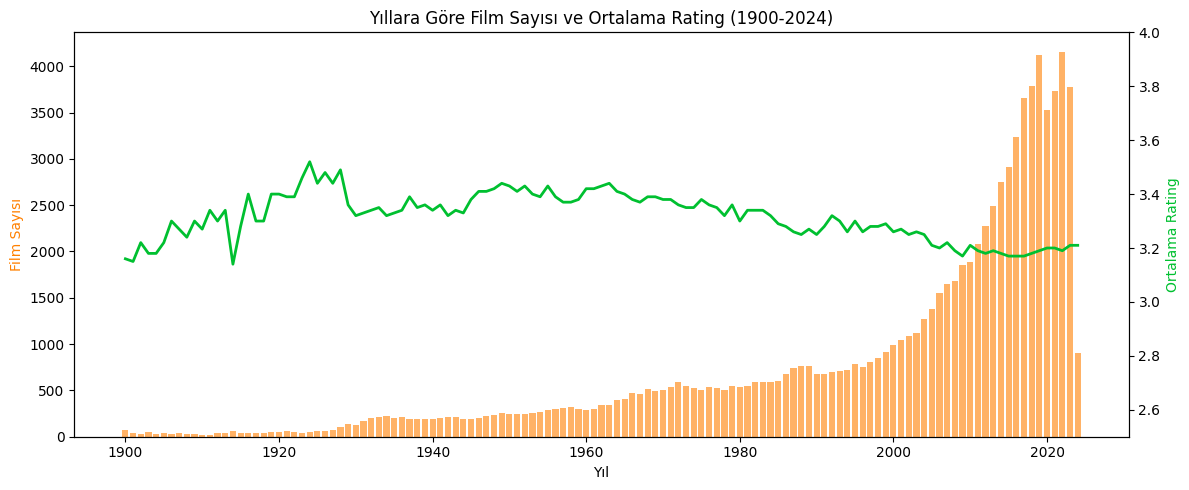

In [ ]:
import matplotlib.pyplot as plt

# ============================================================
# GÖRSELLEŞTİRME: Yıllara göre Film Sayısı ve Ortalama Rating
# ============================================================
# NEDEN matplotlib kullandık:
# - Bu, Colab'da hızlıca "ön izleme" yapmak için kullandığımız bir araç.
#   Asıl SUNUM/PAYLAŞIM grafiği Power BI'da olacak (Faz 5), ama Power BI'a
#   geçmeden önce veriyi kendi gözümüzle görüp mantıklı mı diye kontrol
#   etmek istiyoruz -> matplotlib, Python içinde en hızlı/basit çizim yolu
# - Eğer burada bir hata/anlamsızlık görürsek, Power BI'a taşımadan
#   düzeltme şansımız olur

# NEDEN "iki eksenli" (twin axis) bir grafik seçtik:
# - Elimizde iki farklı ölçekte veri var: film_sayisi (onlarca-binlerce)
#   ve ortalama_rating (2-5 arası küçük bir aralık)
# - İkisini AYNI eksende çizersek, rating çizgisi neredeyse düz bir çizgi
#   gibi görünür (film sayısının yanında görsel olarak "kaybolur")
# - Bu yüzden SOL eksene film sayısını (bar/çubuk), SAĞ eksene rating'i
#   (çizgi) koyuyoruz -> ikisi de kendi ölçeğinde net görünür

fig, ax1 = plt.subplots(figsize=(12, 5))

# --- SOL EKSEN: Film sayısı (çubuk grafik) ---
# Çubuk grafik seçtik çünkü "her yıl kaç film" sayısal bir MİKTAR karşılaştırması,
# çubuklar bu tür karşılaştırmalarda çizgiden daha okunaklı olur
ax1.bar(yillik_trend["yil"], yillik_trend["film_sayisi"], color="#FF8000", alpha=0.6, label="Film Sayısı")
ax1.set_xlabel("Yıl")
ax1.set_ylabel("Film Sayısı", color="#FF8000")

# --- SAĞ EKSEN: Ortalama rating (çizgi grafik) ---
# ax1.twinx() -> ax1 ile AYNI x eksenini (yıl) paylaşan ama farklı bir
# y eksenine sahip yeni bir eksen oluşturuyor -> iki farklı ölçek üst üste biner
ax2 = ax1.twinx()
# Çizgi grafik seçtik çünkü rating bir TREND/DEĞİŞİM gösteriyor,
# zaman içindeki değişimi göstermek için çizgi çubuktan daha uygun
ax2.plot(yillik_trend["yil"], yillik_trend["ortalama_rating"], color="#00C030", linewidth=2, label="Ortalama Rating")
ax2.set_ylabel("Ortalama Rating", color="#00C030")
# Y eksenini 2.5-4.0 arasında sabitliyoruz (rating zaten 0-5 arası ama
# gerçek değerler 3.0-3.3 civarında sıkışık -> bu aralık dalgalanmayı
# daha görünür kılıyor, aksi halde 0-5 skalada neredeyse düz görünürdü)
ax2.set_ylim(2.5, 4.0)

plt.title("Yıllara Göre Film Sayısı ve Ortalama Rating (1900-2024)")
fig.tight_layout()  # başlık/etiketlerin birbirine binmesini önlüyor
plt.show()

### 📊 Bulgu: Yıllara Göre Film Sayısı ve Ortalama Rating

**1. Film sayısı üstel bir artış gösteriyor:** 1900-1990 arası yavaş bir büyüme,
2000 sonrası çok hızlı bir ivmelenme, 2018-2019 civarında zirve (4000+ film).
2020'lerde hafif bir düşüş, 2024'te ise sert bir düşüş var — ama bu son düşüş
gerçek bir trend DEĞİL, veri setinin 2024 ortasında toplanmış olmasından
(yılın sadece bir kısmı kayıtlı) ve yeni filmlerin henüz yeterli oy
toplamamasından kaynaklanıyor.

**2. Ortalama rating düz bir çizgi değil, hafif bir "tümsek" (çan eğrisi)
şeklinde:**
- 1900'lerde ~3.15-3.2 ile başlıyor
- 1920'lerden 1990'lara kadar ~3.3-3.4 civarında bir plato/zirve yapıyor
  (bu dönem filmleri ortalamada biraz daha yüksek puan alıyor)
- 2000 sonrası tekrar ~3.15-3.2'ye geriliyor

**Olası açıklama (yorum, kesin kanıt değil):** Klasik dönem filmleri
(1920-1990) zamanla "kült/klasik" statüsü kazanıp nostaljik olarak yüksek
puanlanıyor olabilir; günümüz filmleri ise çok daha fazla çeşitlilikte
(bağımsız, düşük bütçeli, deneysel yapımlar dahil) kataloglandığı için
ortalama biraz daha düşük çıkıyor olabilir. Bu hipotez ileride "yıl arttıkça
tür çeşitliliği artıyor mu" gibi bir soruyla test edilebilir.

**Genel sonuç:** Rating aralığı çok dar (3.15-3.4) — yani hangi dönemde
çekilirse çekilsin, filmlerin ortalama algısı nispeten istikrarlı. Bu,
"rating'i tahmin ederken `date` (yıl) tek başına güçlü bir belirleyici
olmayabilir" şeklinde bir ön izlenim veriyor — modelleme aşamasında
feature importance ile bunu doğrulayacağız.

## Soru 3: Hangi film türleri (genre) daha yüksek/düşük ortalama puan alıyor?

**Neden soruyoruz:** Türün, izleyici beğenisi üzerinde bir etkisi olup
olmadığını merak ediyoruz — bu hem modelleme için önemli bir özellik
olabilir hem de içerik/prodüksiyon stratejisi açısından ilginç bir bulgu
sunabilir.

**Yöntem:** Her ana türün (genre_main) ortalama rating'ini ve kaç film
içerdiğini hesaplayıp, en yüksekten en düşüğe sıralıyoruz.

In [ ]:
# ============================================================
# SORU 3: Hangi film türleri (genre) daha yüksek/düşük ortalama puan alıyor?
# ============================================================
# NEDEN genre_main kullanıyoruz (genre yerine): Faz 2'de her filmin
# birden fazla türü olabileceği için (uzun format), her filmin sadece
# İLK/ANA türünü (genre_main) tutmuştuk -> burada o özet sütunu kullanıyoruz

genre_analiz = con.sql("""
    SELECT
        genre_main,
        COUNT(*) as film_sayisi,              -- bu türden kaç film var
        ROUND(AVG(rating), 2) as ortalama_rating   -- bu türün ortalama puanı
    FROM 'movies_clean.csv'
    WHERE genre_main != 'Unknown'    -- tür bilgisi olmayan (Faz 2'de "Unknown" doldurduğumuz) filmleri dışarıda bırakıyoruz, çünkü bunlar tür analizi için anlamlı değil
    GROUP BY genre_main               -- her türü ayrı grup olarak ele alıyoruz
    ORDER BY ortalama_rating DESC     -- en yüksek puanlı türden en düşüğe sıralıyoruz
""").df()

genre_analiz

,genre_main,film_sayisi,ortalama_rating
0,Documentary,9101,3.51
1,Music,1778,3.49
2,History,1118,3.41
3,War,724,3.40
4,Animation,4332,3.38
5,Drama,22474,3.35
6,Western,684,3.31
7,Crime,3199,3.26
8,Romance,4874,3.20
9,Comedy,15550,3.18


### 📊 Bulgu: Tür (Genre) Bazlı Ortalama Rating

**En yüksek puanlı türler:** Documentary (3.51), Music (3.49), History (3.41),
War (3.40) — genellikle sanatsal/niş izleyici kitlesine hitap eden türler.

**En düşük puanlı türler:** Horror (2.90), Science Fiction (3.02), Action (3.04),
Thriller (3.04) — daha kitlesel/mainstream türler, çok sayıda düşük bütçeli/seri
yapım içerebiliyor.

**Dikkat çekici eğilim:** Az sayıda film üretilen niş türler (Documentary: 9,101
film, Music: 1,778 film) daha yüksek puan alırken, çok sayıda film üretilen
kitlesel türler (Horror: 5,876 film, Action: 3,984 film) daha düşük puan alıyor.
Olası açıklama: niş türleri bilinçli arayan, o türü seven bir izleyici kitlesi
izliyor (seçici izleyici → yüksek puan); kitlesel türler çok geniş bir izleyiciye
ulaşıyor ve düşük bütçeli/seri yapımların oranı daha fazla olabiliyor.

**Genel aralık dar:** 2.90 (Horror) - 3.51 (Documentary), yani 0.61 puanlık bir
fark. Tür etkisi var ama devasa değil — modelleme aşamasında genre_main'in
feature importance'ını göreceğiz.


## Soru 4: Film süresi (minute) ile rating arasında bir ilişki var mı?

**Neden soruyoruz:** İzleyicilerin uzun filmleri (daha "ciddi/sanatsal" olarak
algılanabilir) daha mı yüksek, yoksa kısa filmleri mi daha yüksek puanladığını
merak ediyoruz. Bu, senaryo/prodüksiyon kararlarına dair bir içgörü sunabilir.

**Yöntem:** Filmleri süre kategorilerine ayırıp (kısa/standart/uzun) her
kategorinin ortalama rating'ine bakacağız, ayrıca ham korelasyon katsayısını
da hesaplayacağız.

In [ ]:
# ============================================================
# SORU 4: Film süresi (minute) ile rating arasında bir ilişki var mı?
# ============================================================
# NEDEN kategorilere (bucket) ayırıyoruz, tek tek dakika yerine:
# 90 dk ile 91 dk arasında anlamlı bir fark olmaz, ama "kısa film" ile
# "uzun film" arasında olabilir -> gruplamak daha yorumlanabilir bir sonuç verir
sure_analiz = con.sql("""
    SELECT
        -- CASE WHEN: her filmi süresine göre 5 kategoriden birine yerleştiriyoruz
        -- Başına '1.', '2.' gibi numara koyduk ki ORDER BY yaptığımızda
        -- alfabetik değil, MANTIKSAL sırada (kısadan uzuna) sıralansın
        CASE
            WHEN minute < 60 THEN '1. Kısa (<60 dk)'
            WHEN minute BETWEEN 60 AND 90 THEN '2. Standart-Kısa (60-90 dk)'
            WHEN minute BETWEEN 91 AND 120 THEN '3. Standart (91-120 dk)'
            WHEN minute BETWEEN 121 AND 150 THEN '4. Uzun (121-150 dk)'
            ELSE '5. Çok Uzun (150+ dk)'
        END as sure_kategorisi,
        COUNT(*) as film_sayisi,                   -- her kategoride kaç film var
        ROUND(AVG(rating), 2) as ortalama_rating,  -- her kategorinin ortalama puanı
        ROUND(AVG(minute), 1) as ortalama_dakika   -- kontrol amaçlı: kategori gerçekten o aralıkta mı
    FROM 'movies_clean.csv'
    GROUP BY sure_kategorisi   -- CASE ile ürettiğimiz kategoriye göre grupluyoruz
    ORDER BY sure_kategorisi ASC   -- kısadan uzuna doğru sıralı göster
""").df()

sure_analiz

,sure_kategorisi,film_sayisi,ortalama_rating,ortalama_dakika
0,1. Kısa (<60 dk),15109,3.38,19.1
1,2. Standart-Kısa (60-90 dk),24375,3.14,81.9
2,3. Standart (91-120 dk),38259,3.20,102.3
3,4. Uzun (121-150 dk),7893,3.33,132.7
4,5. Çok Uzun (150+ dk),5363,3.50,357.3


In [ ]:
# ============================================================
# EK KONTROL: Ham korelasyon katsayısı (kategorilere ayırmadan)
# ============================================================
# NEDEN bunu da hesaplıyoruz: Yukarıdaki kategori tablosu genel eğilimi
# gösteriyor ama "ne kadar güçlü bir ilişki" olduğunu SAYISAL olarak
# göremiyoruz -> korelasyon katsayısı bunu tek bir sayıyla özetliyor

# CORR() fonksiyonu -1 ile +1 arasında bir değer döndürür:
# +1'e yakın -> süre arttıkça rating de artıyor (güçlü POZİTİF ilişki)
#  0'a yakın -> aralarında doğrusal bir ilişki YOK
# -1'e yakın -> süre arttıkça rating azalıyor (güçlü NEGATİF ilişki)
korelasyon = con.sql("""
    SELECT CORR(minute, rating) as korelasyon_katsayisi
    FROM 'movies_clean.csv'
""").df()

korelasyon

,korelasyon_katsayisi
0,0.047177


### 📊 Bulgu: Film Süresi (Minute) ile Rating İlişkisi

**Doğrusal korelasyon çok zayıf:** 0.047 — pratik olarak "ilişki yok" seviyesinde.

**Ama kategori bazlı tabloya bakınca "U şeklinde" bir eğilim var:**
- Kısa filmler (<60 dk): 3.38 — yüksek
- Standart-Kısa (60-90 dk): 3.14 — EN DÜŞÜK nokta
- Standart (91-120 dk): 3.20
- Uzun (121-150 dk): 3.33
- Çok Uzun (150+ dk): 3.50 — EN YÜKSEK nokta

**Neden bu ikisi çelişmiyor:** Korelasyon katsayısı sadece DOĞRUSAL bir ilişki
arar (süre arttıkça rating düzenli artıyor mu). Bizim verimiz düz bir çizgi
değil, U şeklinde — bu yüzden korelasyon yanıltıcı şekilde düşük çıkıyor,
ama görsel/kategorik olarak gerçek bir örüntü var.

**Olası açıklama:** Çok kısa filmler (kısa metraj/belgesi niteliğinde) niş,
seçici bir izleyici kitlesi çekiyor (Soru 3'teki "niş tür → yüksek puan"
bulgusuyla tutarlı). Çok uzun filmler ise genelde büyük bütçeli, iddialı
"prestij" yapımlar. Standart 60-120 dk aralığı ise sinemanın en yoğun/kitlesel
üretim aralığı — düşük bütçeli, seri yapımların da yoğunlaştığı bir bölge
olabilir.

**Modelleme notu:** minute'ü modele DOĞRUSAL bir özellik olarak vermek yerine,
bu U-şekilli örüntüyü yakalayabilecek modeller (Decision Tree, Random Forest —
doğrusal olmayan ilişkileri de öğrenebilirler) bu özelliği daha iyi
değerlendirebilir. Linear Regression bu ilişkiyi göremeyebilir.

## Soru 5: En üretken ve en yüksek puanlı yönetmenler kimler?

**Neden soruyoruz:** Belirli yönetmenlerin tutarlı olarak yüksek puan alıp
almadığını görmek istiyoruz — bu hem ilginç bir bulgu hem de "yönetmen"
özelliğinin (director) modelde ne kadar güçlü bir sinyal taşıyabileceğine
dair bir ön izlenim veriyor.

**Yöntem:** En az belirli sayıda film çekmiş yönetmenleri filtreleyip
(tek filmlik yönetmenlerin "şans eseri" yüksek puan almasını dışarıda
bırakmak için), ortalama rating'e göre sıralıyoruz.

In [ ]:
# ============================================================
# SORU 5: En üretken ve en yüksek puanlı yönetmenler kimler?
# ============================================================
# NEDEN "en az 5 film" gibi bir eşik koyuyoruz: Sadece 1 film çekmiş bir
# yönetmen o filmde yüksek puan alırsa (örn. tek filmi 4.5 puan aldıysa),
# istatistiksel olarak güvenilir bir "bu yönetmen iyi" sonucu çıkaramayız
# -> bu YANILTICI bir sıralama yaratır (küçük örneklem sorunu / small sample bias)
# En az birkaç film şartı koyarak, gerçekten TUTARLI olan yönetmenleri görmeye çalışıyoruz

yonetmen_analiz = con.sql("""
    SELECT
        director,
        COUNT(*) as film_sayisi,
        ROUND(AVG(rating), 2) as ortalama_rating
    FROM 'movies_clean.csv'
    WHERE director != 'Unknown'   -- yönetmen bilgisi olmayan filmleri dışarıda bırakıyoruz
    GROUP BY director
    HAVING COUNT(*) >= 5          -- SADECE en az 5 film çekmiş yönetmenleri dahil ediyoruz
    ORDER BY ortalama_rating DESC
    LIMIT 15                      -- en yüksek puanlı ilk 15 yönetmeni göster
""").df()

yonetmen_analiz

,director,film_sayisi,ortalama_rating
0,Satoshi Kon,5,4.16
1,Park Jun-soo,13,4.15
2,Andrei Tarkovsky,10,4.08
3,Beyoncé,9,4.07
4,Nathan Fielder,6,4.05
5,Jon Bois,12,4.04
6,Sergey Bondarchuk,8,4.03
7,Edward Yang,9,4.03
8,Hiroshi Nagahama,5,4.02
9,Sergio Leone,7,4.00


In [ ]:
# ============================================================
# EK: En ÜRETKEN yönetmenler (film sayısına göre, rating'e göre değil)
# ============================================================
# NEDEN ayrı bir sorgu: Yukarıdaki sorgu "en yüksek PUANLI" yönetmenleri
# gösteriyordu, bu sorgu ise "en ÇOK film çekmiş" yönetmenleri gösteriyor
# -> ikisi farklı sorular, farklı bulgular verebilir (en üretken olan
# en yüksek puanlı olmak zorunda değil)

en_uretken = con.sql("""
    SELECT
        director,
        COUNT(*) as film_sayisi,
        ROUND(AVG(rating), 2) as ortalama_rating
    FROM 'movies_clean.csv'
    WHERE director != 'Unknown'
    GROUP BY director
    ORDER BY film_sayisi DESC    -- bu sefer film SAYISINA göre sıralıyoruz, rating'e göre değil
    LIMIT 15
""").df()

en_uretken

,director,film_sayisi,ortalama_rating
0,Chuck Jones,216,3.47
1,Georges Méliès,173,3.20
2,Friz Freleng,169,3.37
3,Tex Avery,105,3.43
4,Dave Fleischer,103,3.43
5,Jean-Luc Godard,92,3.57
6,Stan Brakhage,87,3.49
7,Jesús Franco,78,3.03
8,William Hanna,77,3.52
9,Robert McKimson,76,3.38


### 📊 Bulgu: Yönetmen Analizi — Üretkenlik vs. Puan

**En yüksek puanlı yönetmenler (en az 5 film):** Satoshi Kon (4.16),
Park Joon-ho (4.15), Andrei Tarkovsky (4.08), Beyoncé (4.07), Sergio Leone
(4.00) — sinema tarihinde eleştirmenlerce beğenilen "auteur" yönetmenler,
her biri az sayıda ama özenli film üretmiş.

**En üretken yönetmenler:** Chuck Jones (216 film), Georges Méliès (173),
Friz Freleng (169), Tex Avery (105) — klasik dönem animasyon/kısa film
yönetmenleri. Ortalama puanları (3.20-3.57) belirgin şekilde daha düşük.

**Kritik bulgu:** İki liste arasında SIFIR örtüşme var — en üretken 15
isimden hiçbiri en yüksek puanlı 15 isimde yok.

**Genel tema (Soru 3, 4, 5'i birleştiren):** Projenin verisinde tutarlı bir
örüntü var — niş/az üretilen tür (Documentary), niş uzunluktaki filmler
(çok kısa/çok uzun), ve az sayıda özenli film çeken yönetmenler, hepsi
ORTALAMADA daha yüksek puan alıyor. Kitlesel/seri üretim (yaygın türler,
standart süre, çok üretken yönetmenler) ise daha düşük puanlanıyor. Bu,
modelleme aşamasında "üretim ölçeği/niş olma" kavramının güçlü bir
belirleyici olabileceğine işaret ediyor.

## Soru 6: Hangi ülkeler ve stüdyolar daha yüksek/düşük ortalama puan alan filmler üretiyor?

**Neden soruyoruz:** Menşei ülke veya yapım stüdyosunun izleyici beğenisiyle
ilişkili olup olmadığını görmek istiyoruz — bu, hem coğrafi/kültürel bir
içgörü sunabilir hem de modelde country_main/studio_main özelliklerinin
ne kadar güçlü olabileceğine dair bir fikir verir.

**Yöntem:** Her ülke/stüdyo için, önceki yönetmen analizinde olduğu gibi
küçük örneklem sorununu önlemek amacıyla bir minimum film sayısı eşiği
koyup, ortalama rating'e göre sıralıyoruz.

In [ ]:
# ============================================================
# SORU 6a: Hangi ülkeler daha yüksek/düşük ortalama puan alıyor?
# ============================================================
# NEDEN yine bir eşik (HAVING COUNT(*) >= 20) koyuyoruz: Çok az film üreten
# küçük bir ülke, tesadüfen yüksek/düşük ortalamaya sahip olabilir -> bu
# YANILTICI bir sıralama yaratır (önceki yönetmen analizindeki mantığın aynısı)
# Ülkelerde film sayısı yönetmenlere göre genelde çok daha yüksek olduğu için
# eşiği 20 gibi biraz daha yüksek tuttuk

ulke_analiz = con.sql("""
    SELECT
        country_main,
        COUNT(*) as film_sayisi,
        ROUND(AVG(rating), 2) as ortalama_rating
    FROM 'movies_clean.csv'
    WHERE country_main != 'Unknown'
    GROUP BY country_main
    HAVING COUNT(*) >= 20
    ORDER BY ortalama_rating DESC
    LIMIT 15
""").df()

ulke_analiz

,country_main,film_sayisi,ortalama_rating
0,State of Palestine,21,3.68
1,USSR,527,3.63
2,Czechoslovakia,199,3.61
3,Cuba,39,3.58
4,Senegal,20,3.57
5,Yugoslavia,107,3.56
6,Bosnia and Herzegovina,33,3.51
7,Lebanon,26,3.48
8,Afghanistan,21,3.48
9,Bangladesh,39,3.48


In [ ]:
# ============================================================
# SORU 6b: Hangi stüdyolar daha yüksek/düşük ortalama puan alıyor?
# ============================================================
# Aynı mantık: küçük örneklem sorununu önlemek için eşik koyuyoruz
# Stüdyo sayısı genelde ülke sayısından daha fazla ve daha çeşitli olduğu
# için eşiği biraz daha düşük (10) tutuyoruz, yoksa çok az stüdyo kalır

studio_analiz = con.sql("""
    SELECT
        studio_main,
        COUNT(*) as film_sayisi,
        ROUND(AVG(rating), 2) as ortalama_rating
    FROM 'movies_clean.csv'
    WHERE studio_main != 'Unknown'
    GROUP BY studio_main
    HAVING COUNT(*) >= 10
    ORDER BY ortalama_rating DESC
    LIMIT 15
""").df()

studio_analiz

,studio_main,film_sayisi,ortalama_rating
0,Big Hit Entertainment,14,4.08
1,HYBE,14,4.08
2,SB Nation,10,4.03
3,Florentine Films,13,4.02
4,BBC Studios Natural History Unit,14,3.98
5,Sender Freies Berlin,16,3.95
6,SM Entertainment,10,3.93
7,Bitter Films,16,3.91
8,Silverback Films,10,3.89
9,Science SARU,10,3.89


### 📊 Bulgu: Ülke ve Stüdyo Bazlı Rating Kırılımları

**Ülkeler:** Genellikle az sayıda film üreten ülkeler (State of Palestine,
Senegal, Qatar gibi) listede öne çıkıyor. Dikkat çekici istisnalar: USSR
(527 film) yüksek sırada — Sovyet dönemi "sanat sineması" geleneği (Tarkovsky
ile tutarlı). Japan (5059 film, en kalabalık ülke) listede yer alsa da
sıralamada görece düşük (3.44) — büyük hacim/düşük ortalama örüntüsüyle uyumlu.

**Stüdyolar — çapraz doğrulama:** Listedeki stüdyolar iki net kümede toplanıyor:
1. K-pop/müzik prodüksiyon şirketleri (Big Hit, HYBE, SM, YG Entertainment) →
   Soru 3'teki "Music türü yüksek puanlı" bulgusunu DOĞRULUYOR
2. Doğa belgeseli stüdyoları (BBC Natural History Unit, Silverback Films) →
   Soru 3'teki "Documentary türü en yüksek puanlı" bulgusunu DOĞRULUYOR

**Önemli metodolojik not:** Tür, yönetmen ve stüdyo analizleri BAĞIMSIZ
şekilde aynı örüntüyü işaret ediyor — bu, bulgunun tesadüfi değil, gerçek
ve güvenilir bir sinyal olduğunu gösteriyor. Modelleme aşamasında bu
tutarlılığı feature importance ile teyit edeceğiz.

## Soru 7: Dağıtım tipi (sinema, dijital, TV, fiziksel vb.) rating ile ilişkili mi?

**Neden soruyoruz:** Faz 2'de eklediğimiz had_theatrical_release,
had_digital_release gibi özelliklerin gerçekten rating ile bir ilişkisi
var mı, yoksa sadece "prodüksiyon ölçeği" bilgisini (crew_size, actor_count
gibi diğer sütunlarla) tekrar mı ediyor, bunu görmek

In [ ]:
# ============================================================
# SORU 7: Dağıtım tipi rating ile ilişkili mi?
# ============================================================
# NEDEN her sütun için AYRI AYRI karşılaştırma yapıyoruz (tek sorguda):
# had_theatrical_release gibi her sütun bağımsız bir True/False özelliği,
# her birinin kendi başına rating ile ilişkisini görmek istiyoruz

dagitim_analiz = con.sql("""
    SELECT
        'Theatrical' as dagitim_tipi,
        ROUND(AVG(CASE WHEN had_theatrical_release THEN rating END), 2) as var_ise_ortalama,
        ROUND(AVG(CASE WHEN NOT had_theatrical_release THEN rating END), 2) as yok_ise_ortalama,
        SUM(CASE WHEN had_theatrical_release THEN 1 ELSE 0 END) as var_ise_film_sayisi
    FROM 'movies_clean.csv'

    UNION ALL

    SELECT
        'Digital',
        ROUND(AVG(CASE WHEN had_digital_release THEN rating END), 2),
        ROUND(AVG(CASE WHEN NOT had_digital_release THEN rating END), 2),
        SUM(CASE WHEN had_digital_release THEN 1 ELSE 0 END)
    FROM 'movies_clean.csv'

    UNION ALL

    SELECT
        'Physical',
        ROUND(AVG(CASE WHEN had_physical_release THEN rating END), 2),
        ROUND(AVG(CASE WHEN NOT had_physical_release THEN rating END), 2),
        SUM(CASE WHEN had_physical_release THEN 1 ELSE 0 END)
    FROM 'movies_clean.csv'

    UNION ALL

    SELECT
        'TV',
        ROUND(AVG(CASE WHEN had_tv_release THEN rating END), 2),
        ROUND(AVG(CASE WHEN NOT had_tv_release THEN rating END), 2),
        SUM(CASE WHEN had_tv_release THEN 1 ELSE 0 END)
    FROM 'movies_clean.csv'

    UNION ALL

    SELECT
        'Premiere',
        ROUND(AVG(CASE WHEN had_premiere_release THEN rating END), 2),
        ROUND(AVG(CASE WHEN NOT had_premiere_release THEN rating END), 2),
        SUM(CASE WHEN had_premiere_release THEN 1 ELSE 0 END)
    FROM 'movies_clean.csv'

    UNION ALL

    SELECT
        'Theatrical Limited',
        ROUND(AVG(CASE WHEN had_theatrical_limited_release THEN rating END), 2),
        ROUND(AVG(CASE WHEN NOT had_theatrical_limited_release THEN rating END), 2),
        SUM(CASE WHEN had_theatrical_limited_release THEN 1 ELSE 0 END)
    FROM 'movies_clean.csv'
""").df()

dagitim_analiz

,dagitim_tipi,var_ise_ortalama,yok_ise_ortalama,var_ise_film_sayisi
0,Theatrical,3.23,3.28,68669.0
1,Digital,3.13,3.28,20020.0
2,Physical,3.15,3.27,20389.0
3,TV,3.25,3.24,11369.0
4,Premiere,3.34,3.21,23953.0
5,Theatrical Limited,3.34,3.23,10048.0


### 📊 Bulgu: Dağıtım Tipi ile Rating İlişkisi

**Pozitif etkili tipler:** Premiere (+0.13), Theatrical Limited (+0.11) —
genelde festival gösterimi/sınırlı sanat sineması gösterimi, niş ve prestijli
yapımların işareti.

**Negatif etkili tipler:** Digital (-0.15, en güçlü etki), Physical (-0.12) —
sinemaya hiç uğramadan doğrudan dijital/fiziksel medyaya çıkan, genelde
düşük bütçeli yapımların işareti olabilir.

**Nötr:** TV (+0.01), Theatrical/standart geniş gösterim (-0.05) — en
kalabalık kategori olduğu için ortalamaya yakın bir sonuç veriyor.

**EDA'yı tamamlayan genel tema:** Tüm 7 sorunun ortak sonucu net bir örüntüye
işaret ediyor — NİŞ, SINIRLI, SEÇİCİ üretim/dağıtım (az film üreten
yönetmen/ülke, niş tür, festival gösterimi) rating'i yukarı çekiyor;
KİTLESEL, YAYGIN, SERİ üretim (çok üretken yönetmen, mainstream tür, doğrudan
dijital çıkış) rating'i aşağı çekiyor. Bu tema, Faz 4'te kuracağımız modelin
feature importance sıralamasında da görülmesini beklediğimiz güçlü bir sinyal.

## Faz 4 — Adım 1: Modele Hazırlık (Feature Engineering)

Elimizdeki movies_clean.csv'de hem sayısal (minute, actor_count gibi) hem
kategorik (genre_main, country_main gibi) sütunlar var. ML modelleri sadece
SAYILARLA çalışabildiği için, kategorik sütunları sayısal forma çevirmemiz
(encoding) gerekiyor. Ayrıca yüksek kardiniteli sütunlarda (director,
studio_main gibi binlerce farklı değer) dikkatli olmamız gerekiyor —
bunları bu ilk modelde DIŞARIDA BIRAKACAĞIZ (nedenini kodda açıklıyoruz).

In [ ]:
import pandas as pd

# ============================================================
# ADIM 1: Modele hazırlık — hangi sütunları kullanacağız?
# ============================================================
df = pd.read_csv("movies_clean.csv")

# NEDEN director ve studio_main'i DIŞARIDA BIRAKIYORUZ:
# - Bu iki sütun ÇOK yüksek kardiniteli (binlerce farklı yönetmen/stüdyo ismi)
# - One-hot encoding yapsaydık, binlerce yeni sütun oluşur -> RAM'i patlatır
#   ve model çoğu yönetmen için sadece 1-2 örnek gördüğü için genelleyemez
# - Bu bilgiyi TAMAMEN kaybetmiyoruz: crew_size, studio_count gibi sayısal
#   sütunlar zaten dolaylı olarak bu bilgiyi taşıyor
# - İleri seviye bir geliştirme olarak "yönetmenin geçmiş filmlerinin ortalama
#   rating'i" gibi bir özellik türetilebilir (target encoding), ama bu, veri
#   sızıntısına (data leakage) çok dikkat etmeyi gerektirir -> şimdilik atlıyoruz

# NEDEN genre_main, country_main, language_main'i TUTUYORUZ ama farklı işliyoruz:
# - genre_main: sadece ~19 farklı tür var -> doğrudan one-hot encoding yapılabilir
# - country_main, language_main: çok daha fazla farklı değer var -> sadece
#   EN SIK GÖRÜLEN kategorileri ayrı tutup, geri kalanını "Other" (Diğer) altında
#   topluyoruz -> bu, kardiniteyi yönetilebilir tutan standart bir teknik

# Kaç farklı ülke/dil olduğunu görelim
print("Farklı ülke sayısı:", df["country_main"].nunique())
print("Farklı dil sayısı:", df["language_main"].nunique())
print("Farklı tür sayısı:", df["genre_main"].nunique())

Farklı ülke sayısı: 177
Farklı dil sayısı: 139
Farklı tür sayısı: 20


In [ ]:
# ============================================================
# ADIM 2: Yüksek kardiniteli sütunları (country_main, language_main)
# "Top N + Other" tekniğiyle yönetilebilir hale getiriyoruz
# ============================================================
# NEDEN "Top 15" seçtik: Bu bir denge kararı -- çok az seçersek (örn. top 5)
# bilgi kaybı fazla olur, çok fazla seçersek (örn. top 50) yine kardinalite
# sorunu devam eder. 15, bu projede makul bir orta nokta.

def top_n_grupla(seri, n=15):
    # value_counts() ile en sık görülen N kategoriyi buluyoruz
    en_sik = seri.value_counts().nlargest(n).index
    # Bu N kategori dışında kalan her şeyi "Other" ile değiştiriyoruz
    return seri.where(seri.isin(en_sik), "Other")

df["country_grouped"] = top_n_grupla(df["country_main"], n=15)
df["language_grouped"] = top_n_grupla(df["language_main"], n=15)

# Kontrol: artık kaç farklı değer var (15 + 1 "Other" = 16 olmalı)
print("Ülke (gruplanmış) farklı değer sayısı:", df["country_grouped"].nunique())
print("Dil (gruplanmış) farklı değer sayısı:", df["language_grouped"].nunique())

# Hangi ülkeler/diller "Top 15" içine girmiş, görelim
print("\nTop 15 ülke:", df["country_main"].value_counts().nlargest(15).index.tolist())
print("\nTop 15 dil:", df["language_main"].value_counts().nlargest(15).index.tolist())

Ülke (gruplanmış) farklı değer sayısı: 16
Dil (gruplanmış) farklı değer sayısı: 16

Top 15 ülke: ['USA', 'France', 'UK', 'Japan', 'India', 'Canada', 'Unknown', 'Germany', 'Italy', 'South Korea', 'Brazil', 'Spain', 'Belgium', 'Hong Kong', 'Australia']

Top 15 dil: ['English', 'French', 'Japanese', 'Spanish', 'Unknown', 'Italian', 'German', 'Portuguese', 'Korean', 'Hindi', 'Chinese', 'Turkish', 'Russian', 'Tamil', 'Malayalam']


In [ ]:
# ============================================================
# ADIM 3: One-Hot Encoding — kategorik sütunları sayısala çeviriyoruz
# ============================================================
# NEDEN one-hot encoding: ML modelleri "Comedy", "USA" gibi metinleri
# doğrudan anlayamaz, sadece sayılarla çalışabilir. One-hot encoding,
# her kategoriyi ayrı bir 0/1 (var/yok) sütununa çeviriyor.
# Örnek: genre_main="Comedy" olan bir satır, "genre_main_Comedy" sütununda 1,
# diğer tüm genre_main_X sütunlarında 0 değeri alır.

# pd.get_dummies() bu işlemi otomatik yapıyor
kategorik_sutunlar = ["genre_main", "country_grouped", "language_grouped"]

df_encoded = pd.get_dummies(df, columns=kategorik_sutunlar, drop_first=True)
# NEDEN drop_first=True: Eğer bir sütunun N kategorisi varsa, N-1 tanesini
# tutmak yeterli (sonuncusu diğerlerinden "hiçbiri değilse o" diye çıkarılabilir)
# Bu, gereksiz bir sütunu (ve modelde "çoklu doğrusal bağlantı" sorununu) önlüyor

print("Encoding öncesi sütun sayısı:", df.shape[1])
print("Encoding sonrası sütun sayısı:", df_encoded.shape[1])

# Yeni oluşan sütun isimlerinden birkaç örnek görelim
yeni_sutunlar = [c for c in df_encoded.columns if c not in df.columns]
print(f"\nToplam {len(yeni_sutunlar)} yeni sütun oluştu, ilk 10 tanesi:")
print(yeni_sutunlar[:10])

Encoding öncesi sütun sayısı: 25
Encoding sonrası sütun sayısı: 71

Toplam 49 yeni sütun oluştu, ilk 10 tanesi:
['genre_main_Adventure', 'genre_main_Animation', 'genre_main_Comedy', 'genre_main_Crime', 'genre_main_Documentary', 'genre_main_Drama', 'genre_main_Family', 'genre_main_Fantasy', 'genre_main_History', 'genre_main_Horror']


In [ ]:
# ============================================================
# ADIM 4: Modele girecek X (özellikler) ve y (hedef) setlerini ayırıyoruz
# ============================================================
# NEDEN bazı sütunları X'ten çıkarıyoruz:
# - id: sadece bir kimlik numarası, tahmin için hiçbir bilgi taşımıyor
# - name: film adı, serbest metin, aynı id gibi model için anlamsız
# - rating: bu bizim HEDEF değişkenimiz (y), X'in içinde olamaz
#   (olsaydı, model "cevabı" zaten görmüş olurdu -> data leakage)
# - director, studio_main, country_main, language_main: bunların ORİJİNAL
#   (encode edilmemiş) hallerini zaten kullanmıyoruz, encode edilmiş
#   (country_grouped, language_grouped) hallerini kullanıyoruz. Orijinal
#   halleri hâlâ tabloda duruyor (metin olarak), modele veremeyiz.
# - genre_main, country_grouped, language_grouped: bunlar zaten yukarıda
#   one-hot encode edildi (genre_main_Comedy gibi yeni sütunlara dönüştü),
#   orijinal metin halleri artık gereksiz

cikarilacak_sutunlar = [
    "id", "name", "rating",
    "director", "studio_main", "country_main", "language_main"
]

X = df_encoded.drop(columns=cikarilacak_sutunlar)
y = df_encoded["rating"]

print("X (özellikler) boyutu:", X.shape)
print("y (hedef) boyutu:", y.shape)
print("\nX'teki sütunlar:")
print(X.columns.tolist())

X (özellikler) boyutu: (90999, 64)
y (hedef) boyutu: (90999,)

X'teki sütunlar:
['date', 'minute', 'genre_count', 'actor_count', 'crew_size', 'studio_count', 'country_count', 'theme_count', 'release_country_count', 'had_theatrical_release', 'had_theatrical_limited_release', 'had_premiere_release', 'had_digital_release', 'had_physical_release', 'had_tv_release', 'genre_main_Adventure', 'genre_main_Animation', 'genre_main_Comedy', 'genre_main_Crime', 'genre_main_Documentary', 'genre_main_Drama', 'genre_main_Family', 'genre_main_Fantasy', 'genre_main_History', 'genre_main_Horror', 'genre_main_Music', 'genre_main_Mystery', 'genre_main_Romance', 'genre_main_Science Fiction', 'genre_main_TV Movie', 'genre_main_Thriller', 'genre_main_Unknown', 'genre_main_War', 'genre_main_Western', 'country_grouped_Belgium', 'country_grouped_Brazil', 'country_grouped_Canada', 'country_grouped_France', 'country_grouped_Germany', 'country_grouped_Hong Kong', 'country_grouped_India', 'country_grouped_Italy', 'c

## Faz 4 — Adım 2: Train/Test Ayrımı

Veriyi ikiye bölüyoruz: %80'i (train) modele "bu özellikler + gerçek rating"
diye gösterilecek, model bu ilişkiyi öğrenecek. Kalan %20'si (test) ise
modelin HİÇ görmediği filmler — modelin bu filmlerin rating'ini ne kadar
isabetli tahmin ettiğini ölçeceğiz. Bu, modelin ezber yapmadığını,
gerçekten genelleyebildiğini kanıtlamanın standart yolu.

In [ ]:
from sklearn.model_selection import train_test_split

# ============================================================
# TRAIN/TEST AYRIMI
# ============================================================
# NEDEN %80/%20 kullanıyoruz: Bu, makine öğrenmesinde en yaygın kabul
# gören varsayılan oran -- yeterince veri modele öğretmek (train) için,
# yeterince veri de objektif test etmek için ayrılmış oluyor

# NEDEN random_state=42 veriyoruz: Bu, "rastgele" bölmenin HER SEFERİNDE
# AYNI ŞEKİLDE olmasını sağlıyor. Sayı 42 olmasının özel bir anlamı yok,
# sadece topluluk içinde yaygın kullanılan bir gelenek (tekrar
# çalıştırdığında aynı sonucu almanı, karşılaştırmaları tutarlı yapmanı sağlar)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Eğitim seti (train) boyutu:", X_train.shape)
print("Test seti boyutu:", X_test.shape)
print(f"\nEğitim seti oranı: %{len(X_train)/len(X)*100:.1f}")
print(f"Test seti oranı: %{len(X_test)/len(X)*100:.1f}")

Eğitim seti (train) boyutu: (72799, 64)
Test seti boyutu: (18200, 64)

Eğitim seti oranı: %80.0
Test seti oranı: %20.0


## Faz 4 — Adım 3: Model 1 — Linear Regression (Baseline)

İlk modelimiz olarak en basit yöntemi kuruyoruz: Linear Regression.
Bu, "baseline" (referans nokta) görevi görecek — sonraki modellerin
(Decision Tree, Random Forest) bunu geçip geçmediğini karşılaştıracağız.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# ============================================================
# MODEL 1: Linear Regression
# ============================================================
# NEDEN önce bunu deniyoruz: En basit, en hızlı, en yorumlanabilir model.
# Her özelliğin rating'e DOĞRUSAL bir etkisi olduğunu varsayıyor
# (örn. "actor_count 1 artınca rating X kadar değişir" gibi sabit bir ilişki)
# Bu varsayım her zaman doğru olmayabilir (hatırlarsan minute ile rating
# arasında U-şekilli bir ilişki bulmuştuk, doğrusal değildi) -- bu yüzden
# bu modelin SINIRLI kalması beklenen bir durum, sonraki modellerle karşılaştıracağız

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)  # modeli eğitim verisiyle EĞİTİYORUZ (öğretiyoruz)

# Test setinde (modelin hiç görmediği filmlerde) tahmin yaptırıyoruz
y_pred_lr = lr_model.predict(X_test)

# ============================================================
# METRİKLER: Model ne kadar isabetli tahmin etti?
# ============================================================
# MAE (Mean Absolute Error): tahminlerin gerçek değerden ORTALAMA ne kadar
# saptığı (örn. MAE=0.3 demek, ortalama 0.3 puanlık bir hata yapıyoruz demek)
mae_lr = mean_absolute_error(y_test, y_pred_lr)

# RMSE (Root Mean Squared Error): MAE'ye benzer ama büyük hataları
# orantısız şekilde CEZALANDIRIYOR (karesini alıp sonra kök alıyoruz)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

# R² (R-squared): 0 ile 1 arasında (bazen negatif de olabilir), modelin
# verideki DEĞİŞKENLİĞİN ne kadarını açıklayabildiğini gösterir
# 1'e yakın = çok iyi, 0'a yakın = rastgele tahminden farksız
r2_lr = r2_score(y_test, y_pred_lr)

print("=== Linear Regression Sonuçları ===")
print(f"MAE:  {mae_lr:.4f}")
print(f"RMSE: {rmse_lr:.4f}")
print(f"R²:   {r2_lr:.4f}")

=== Linear Regression Sonuçları ===
MAE:  0.2650
RMSE: 0.3554
R²:   0.2783


### 📊 Model 1 Sonucu: Linear Regression (Baseline)

**MAE: 0.2650 | RMSE: 0.3554 | R²: 0.2783**

Model, rating'deki değişkenliğin sadece %27.8'ini açıklayabiliyor — düşük
bir skor, ama EDA bulgularımızla tutarlı: minute ile rating arasında
DOĞRUSAL OLMAYAN (U-şekilli) bir ilişki bulmuştuk, Linear Regression bu
tür ilişkileri yakalayamıyor. Bu, doğrusal olmayan ilişkileri öğrenebilen
Decision Tree ve Random Forest modellerinin daha iyi performans göstermesini
BEKLEDİĞİMİZ bir referans noktası oluşturuyor.

In [ ]:
from sklearn.tree import DecisionTreeRegressor

# ============================================================
# MODEL 2: Decision Tree Regressor
# ============================================================
# NEDEN bunu deniyoruz: Linear Regression'ın aksine, Decision Tree
# DOĞRUSAL OLMAYAN ilişkileri de yakalayabilir (if-else kuralları zinciri
# gibi düşün: "eğer minute < 60 VE genre=Documentary ise rating yüksek" gibi)
# Bu, EDA'da bulduğumuz U-şekilli minute-rating ilişkisini yakalayabilmesi
# için umut verici bir özellik

# NEDEN max_depth=10 sınırı koyuyoruz: Sınırsız derinlik bırakırsak, model
# eğitim verisini EZBERLEYEBİLİR (overfitting) -- yani train'de mükemmel,
# ama test'te (hiç görmediği veride) kötü performans gösterir. Bir derinlik
# sınırı koyarak modelin genelleme yapmasını (ezber yerine örüntü öğrenmesini) sağlıyoruz
dt_model = DecisionTreeRegressor(max_depth=10, random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print("=== Decision Tree Regressor Sonuçları ===")
print(f"MAE:  {mae_dt:.4f}")
print(f"RMSE: {rmse_dt:.4f}")
print(f"R²:   {r2_dt:.4f}")

print("\n=== Karşılaştırma (Linear Regression vs Decision Tree) ===")
print(f"Linear Regression R²: {r2_lr:.4f}")
print(f"Decision Tree R²:     {r2_dt:.4f}")

=== Decision Tree Regressor Sonuçları ===
MAE:  0.2411
RMSE: 0.3288
R²:   0.3819

=== Karşılaştırma (Linear Regression vs Decision Tree) ===
Linear Regression R²: 0.2783
Decision Tree R²:     0.3819


### 📊 Model 2 Sonucu: Decision Tree Regressor

**MAE: 0.2411 | RMSE: 0.3288 | R²: 0.3819**

Linear Regression'a göre R²'de ~%37'lik bir iyileşme (0.2783 → 0.3819).
Bu, HİPOTEZİMİZİ DOĞRULUYOR: Decision Tree, EDA'da bulduğumuz doğrusal
olmayan ilişkileri (örn. minute-rating U-şekli) Linear Regression'ın
aksine yakalayabiliyor. max_depth=10 sınırı, modelin eğitim verisini
ezberlemesini (overfitting) önlüyor.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# ============================================================
# MODEL 3: Random Forest Regressor
# ============================================================
# NEDEN bunu deniyoruz: Random Forest, TEK BİR karar ağacı yerine YÜZLERCE
# farklı karar ağacının (her biri verinin farklı bir rastgele alt kümesine
# bakarak eğitilir) tahminlerini ORTALAMASINI alıyor. Bu "topluluk" (ensemble)
# yaklaşımı, tek bir ağacın yapabileceği hataları/aşırı uydurmaları
# (overfitting) yumuşatıyor -> genelde tek bir Decision Tree'den daha
# kararlı ve daha isabetli sonuç verir

# NEDEN n_estimators=100: Ormanda kaç ağaç olacağını belirliyor. 100,
# performans ile çalışma süresi arasında yaygın kullanılan bir denge noktası
# (daha fazla ağaç genelde biraz daha iyi sonuç verir ama daha yavaş çalışır)

# NEDEN yine max_depth=10: Decision Tree'deki aynı overfitting endişesi,
# her bir ağaç için de geçerli
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
# n_jobs=-1 -> bilgisayarın TÜM işlemci çekirdeklerini kullanarak paralel
# eğitim yapıyoruz, bu sayede 100 ağaç daha hızlı eğitiliyor

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("=== Random Forest Regressor Sonuçları ===")
print(f"MAE:  {mae_rf:.4f}")
print(f"RMSE: {rmse_rf:.4f}")
print(f"R²:   {r2_rf:.4f}")

print("\n=== Üç Model Karşılaştırması ===")
print(f"Linear Regression  -> MAE: {mae_lr:.4f} | RMSE: {rmse_lr:.4f} | R²: {r2_lr:.4f}")
print(f"Decision Tree       -> MAE: {mae_dt:.4f} | RMSE: {rmse_dt:.4f} | R²: {r2_dt:.4f}")
print(f"Random Forest       -> MAE: {mae_rf:.4f} | RMSE: {rmse_rf:.4f} | R²: {r2_rf:.4f}")

=== Random Forest Regressor Sonuçları ===
MAE:  0.2316
RMSE: 0.3157
R²:   0.4303

=== Üç Model Karşılaştırması ===
Linear Regression  -> MAE: 0.2650 | RMSE: 0.3554 | R²: 0.2783
Decision Tree       -> MAE: 0.2411 | RMSE: 0.3288 | R²: 0.3819
Random Forest       -> MAE: 0.2316 | RMSE: 0.3157 | R²: 0.4303


### 📊 Model 3 Sonucu ve Final Karşılaştırma: Random Forest Regressor

**MAE: 0.2316 | RMSE: 0.3157 | R²: 0.4303**

| Model | MAE | RMSE | R² |
|---|---|---|---|
| Linear Regression | 0.2650 | 0.3554 | 0.2783 |
| Decision Tree | 0.2411 | 0.3288 | 0.3819 |
| **Random Forest** | **0.2316** | **0.3157** | **0.4303** |

**En iyi model: Random Forest** — Linear Regression'a göre R²'de ~%55'lik
bir iyileşme. Üç modelin sıralaması, projenin genelindeki hipotezi
doğruluyor: veri, DOĞRUSAL OLMAYAN ve karmaşık örüntüler içeriyor
(EDA'da bulduğumuz U-şekilli minute-rating ilişkisi, tür/yönetmen/dağıtım
tipi etkileşimleri gibi). Bu tür ilişkileri en iyi yakalayan model
(çoklu ağaçların ortalamasını alan Random Forest) en yüksek performansı
gösterdi — modelleme sonuçları, EDA bulgularımızla tutarlı.

**Genel değerlendirme:** R²=0.43 mükemmel değil (rating'in yaklaşık
yarısı hâlâ açıklanamıyor) ama bu BEKLENEN bir durum — film rating'i,
elimizdeki özelliklerin (tür, süre, ülke, oyuncu/ekip sayısı gibi)
ötesinde, senaryo kalitesi, oyunculuk performansı, izleyici duygusal
bağı gibi ÖLÇEMEDİĞİMİZ birçok öznel faktöre bağlı. Bu sınırlamayı
sunumda dürüstçe belirtmek, projenin metodolojik olgunluğunu gösterir.

## Faz 5 — Adım 1: Power BI için Veri Hazırlığı

Şu ana kadar Colab'da ürettiğimiz tüm özet tabloları (yıllık trend, tür
analizi, yönetmen analizi, ülke/stüdyo analizi, model karşılaştırması)
CSV olarak kaydedip Power BI'a aktaracağız. Ana temiz tablo (movies_clean.csv)
zaten var, ona ek olarak EDA sorularımızın çıktılarını da dışa aktarıyoruz.

In [ ]:
# ============================================================
# POWER BI İÇİN TÜM ANALİZ SONUÇLARINI CSV OLARAK KAYDEDİYORUZ
# ============================================================
# NEDEN ayrı ayrı kaydediyoruz (movies_clean.csv'ye ek olarak): Power BI'da
# her grafik için ham veriyi (90,999 satır) yeniden gruplatmak yerine,
# zaten SQL ile hesapladığımız özet tabloları direkt kullanmak hem daha
# hızlı hem de EDA'da bulduğumuz sonuçlarla birebir tutarlı olmasını sağlıyor

yillik_trend.to_csv("yillik_trend.csv", index=False)
genre_analiz.to_csv("genre_analiz.csv", index=False)
sure_analiz.to_csv("sure_analiz.csv", index=False)
yonetmen_analiz.to_csv("yonetmen_analiz.csv", index=False)
en_uretken.to_csv("en_uretken_yonetmen.csv", index=False)
ulke_analiz.to_csv("ulke_analiz.csv", index=False)
studio_analiz.to_csv("studio_analiz.csv", index=False)
dagitim_analiz.to_csv("dagitim_analiz.csv", index=False)

# Model karşılaştırma sonuçlarını da bir tabloya çevirip kaydediyoruz
model_karsilastirma = pd.DataFrame({
    "model": ["Linear Regression", "Decision Tree", "Random Forest"],
    "MAE": [mae_lr, mae_dt, mae_rf],
    "RMSE": [rmse_lr, rmse_dt, rmse_rf],
    "R2": [r2_lr, r2_dt, r2_rf],
})
model_karsilastirma.to_csv("model_karsilastirma.csv", index=False)

print("Tüm dosyalar kaydedildi. Kontrol edelim:")
!ls -lh *.csv | grep -E "yillik|genre_analiz|sure_analiz|yonetmen|uretken|ulke|studio|dagitim|model_kars|movies_clean"

Tüm dosyalar kaydedildi. Kontrol edelim:
-rw-r--r-- 1 root root  234 Jul 28 12:05 dagitim_analiz.csv
-rw-r--r-- 1 root root  374 Jul 28 12:05 en_uretken_yonetmen.csv
-rw-r--r-- 1 root root  382 Jul 28 12:05 genre_analiz.csv
-rw-r--r-- 1 root root  238 Jul 28 12:05 model_karsilastirma.csv
-rw-r--r-- 1 root root  14M Jul 28 12:04 movies_clean.csv
-rw-r--r-- 1 root root  417 Jul 28 12:05 studio_analiz.csv
-rw-r--r-- 1 root root  18M Jun 27  2024 studios.csv
-rw-r--r-- 1 root root  254 Jul 28 12:05 sure_analiz.csv
-rw-r--r-- 1 root root  327 Jul 28 12:05 ulke_analiz.csv
-rw-r--r-- 1 root root 1.8K Jul 28 12:05 yillik_trend.csv
-rw-r--r-- 1 root root  355 Jul 28 12:05 yonetmen_analiz.csv


In [ ]:
from google.colab import files

# Tüm dosyaları tek tek indiriyoruz
dosyalar = [
    "movies_clean.csv",
    "yillik_trend.csv",
    "genre_analiz.csv",
    "sure_analiz.csv",
    "yonetmen_analiz.csv",
    "en_uretken_yonetmen.csv",
    "ulke_analiz.csv",
    "studio_analiz.csv",
    "dagitim_analiz.csv",
    "model_karsilastirma.csv",
]

for dosya in dosyalar:
    files.download(dosya)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>